In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
df = pd.read_csv("load_data.csv")

df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


In [5]:
df.shape

(35041, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date_Time                             35041 non-null  object 
 1   Usage_kWh                             33482 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  34165 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  33885 non-null  float64
 4   CO2(tCO2)                             34586 non-null  float64
 5   Lagging_Current_Power_Factor          34691 non-null  float64
 6   Leading_Current_Power_Factor          33570 non-null  float64
 7   NSM                                   34586 non-null  float64
 8   Load_Type                             35041 non-null  object 
dtypes: float64(7), object(2)
memory usage: 2.4+ MB


In [7]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,33482.000000,34165.000000,33885.000000,34586.000000,34691.000000,33570.000000,34586.000000
mean,30.873061,14.704573,4.386097,0.012947,90.740871,94.926552,48013.664032
std,41.415015,20.342721,9.090181,0.019726,39.745395,49.826872,34046.492333
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.310000,2.340000,0.000000,0.000000,66.295000,99.800000,22500.000000
50%,5.290000,5.180000,0.000000,0.000000,90.080000,100.000000,45000.000000
75%,53.560000,23.510000,2.298558,0.020000,100.000000,100.000000,68400.000000
max,435.019069,262.630718,78.809000,0.188166,299.996814,299.969494,248821.810465


In [8]:
df.isnull().sum()

Date_Time                                  0
Usage_kWh                               1559
Lagging_Current_Reactive.Power_kVarh     876
Leading_Current_Reactive_Power_kVarh    1156
CO2(tCO2)                                455
Lagging_Current_Power_Factor             350
Leading_Current_Power_Factor            1471
NSM                                      455
Load_Type                                  0
dtype: int64

In [9]:
df.isnull().sum().sort_values(ascending=False)

Usage_kWh                               1559
Leading_Current_Power_Factor            1471
Leading_Current_Reactive_Power_kVarh    1156
Lagging_Current_Reactive.Power_kVarh     876
CO2(tCO2)                                455
NSM                                      455
Lagging_Current_Power_Factor             350
Date_Time                                  0
Load_Type                                  0
dtype: int64

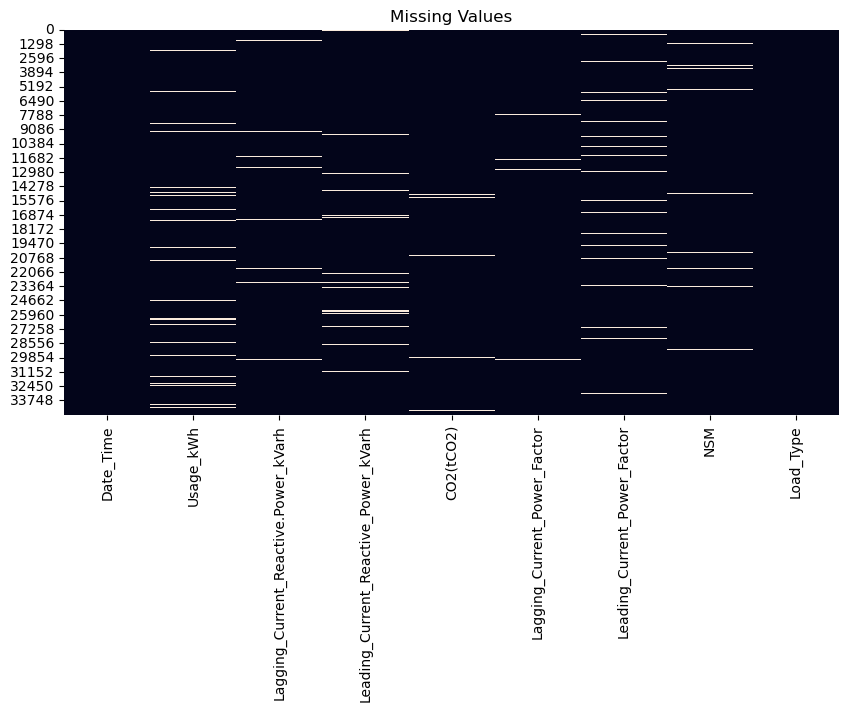

In [10]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

In [11]:
df.duplicated().sum()

0

In [12]:
df['Date_Time'] = pd.to_datetime(
    df['Date_Time'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [13]:
df['Date_Time'].dtype

dtype('<M8[ns]')

In [14]:
df = df.sort_values('Date_Time').reset_index(drop=True)

In [15]:
df[['Date_Time', 'Load_Type']].head()

,Date_Time,Load_Type
0,2018-01-01 00:00:00,Light_Load
1,2018-01-01 00:15:00,Light_Load
2,2018-01-01 00:30:00,Light_Load
3,2018-01-01 00:45:00,Light_Load
4,2018-01-01 01:00:00,Light_Load


In [16]:
df[['Date_Time', 'Load_Type']].tail()

,Date_Time,Load_Type
35036,2018-12-31 22:45:00,Light_Load
35037,2018-12-31 23:00:00,Light_Load
35038,2018-12-31 23:15:00,Light_Load
35039,2018-12-31 23:30:00,Light_Load
35040,2018-12-31 23:45:00,Light_Load


In [17]:
df['Load_Type'].value_counts()

Load_Type
Light_Load      18073
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

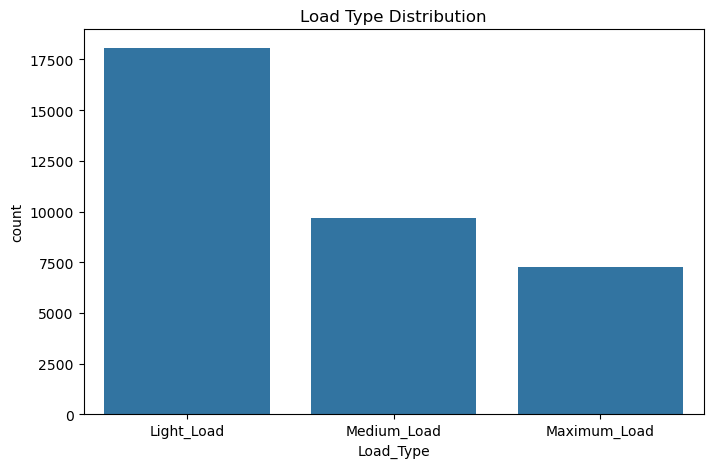

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Load_Type'
)

plt.title("Load Type Distribution")
plt.show()

In [19]:
df['Load_Type'].value_counts(normalize=True) * 100

Load_Type
Light_Load      51.576724
Medium_Load     27.670443
Maximum_Load    20.752832
Name: proportion, dtype: float64

In [20]:
df['Hour'] = df['Date_Time'].dt.hour

In [21]:
df['Minute'] = df['Date_Time'].dt.minute

In [22]:
df['Day'] = df['Date_Time'].dt.day

In [23]:
df['Month'] = df['Date_Time'].dt.month

In [24]:
df['DayOfWeek'] = df['Date_Time'].dt.dayofweek

In [25]:
df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

In [26]:
df[['Date_Time', 'Hour', 'Minute', 'Day', 'Month', 'DayOfWeek', 'IsWeekend']].head()

,Date_Time,Hour,Minute,Day,Month,DayOfWeek,IsWeekend
0,2018-01-01 00:00:00,0,0,1,1,0,0
1,2018-01-01 00:15:00,0,15,1,1,0,0
2,2018-01-01 00:30:00,0,30,1,1,0,0
3,2018-01-01 00:45:00,0,45,1,1,0,0
4,2018-01-01 01:00:00,1,0,1,1,0,0


In [27]:
df['WeekOfYear'] = df['Date_Time'].dt.isocalendar().week.astype(int)

In [28]:
df['Date_Time'].min()

Timestamp('2018-01-01 00:00:00')

In [29]:
df['Date_Time'].max()

Timestamp('2018-12-31 23:45:00')

In [30]:
test_start = pd.Timestamp('2018-12-01')

train_df = df[
    df['Date_Time'] < test_start
].copy()

test_df = df[
    df['Date_Time'] >= test_start
].copy()

In [31]:
print("Training:", train_df.shape)
print("Testing:", test_df.shape)

Training: (32064, 16)
Testing: (2977, 16)


In [32]:
print(
    train_df['Date_Time'].min(),
    train_df['Date_Time'].max()
)

print(
    test_df['Date_Time'].min(),
    test_df['Date_Time'].max()
)

2018-01-01 00:00:00 2018-11-30 23:45:00
2018-12-01 00:00:00 2018-12-31 23:45:00


In [33]:
features = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM',
    'Hour',
    'Minute',
    'Day',
    'Month',
    'DayOfWeek',
    'IsWeekend'
]

In [34]:
X_train = train_df[features]
y_train = train_df['Load_Type']

X_test = test_df[features]
y_test = test_df['Load_Type']

In [35]:
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [36]:
imputer.fit_transform(X_train)

array([[ 3.42      ,  3.46      ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 8.75369243,  2.95      ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 4.        ,  4.46      ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 3.92      ,  2.77      ,  0.36      , ..., 11.        ,
         4.        ,  0.        ],
       [ 3.89      ,  4.31922367,  0.5       , ..., 11.        ,
         4.        ,  0.        ],
       [ 3.82      ,  2.45      ,  0.54      , ..., 11.        ,
         4.        ,  0.        ]])

In [37]:
imputer.transform(X_test)

array([[ 3.35      ,  2.48      ,  0.04      , ..., 12.        ,
         5.        ,  1.        ],
       [ 3.89      ,  2.7       ,  0.4       , ..., 12.        ,
         5.        ,  1.        ],
       [ 6.96981938,  2.66      ,  0.43      , ..., 12.        ,
         5.        ,  1.        ],
       ...,
       [ 3.74      ,  3.74      ,  0.        , ..., 12.        ,
         0.        ,  0.        ],
       [ 3.78      ,  3.17      ,  0.07      , ..., 12.        ,
         0.        ,  0.        ],
       [ 3.78      ,  3.06      ,  0.11      , ..., 12.        ,
         0.        ,  0.        ]])

In [38]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [39]:
label_encoder.classes_

array(['Light_Load', 'Maximum_Load', 'Medium_Load'], dtype=object)

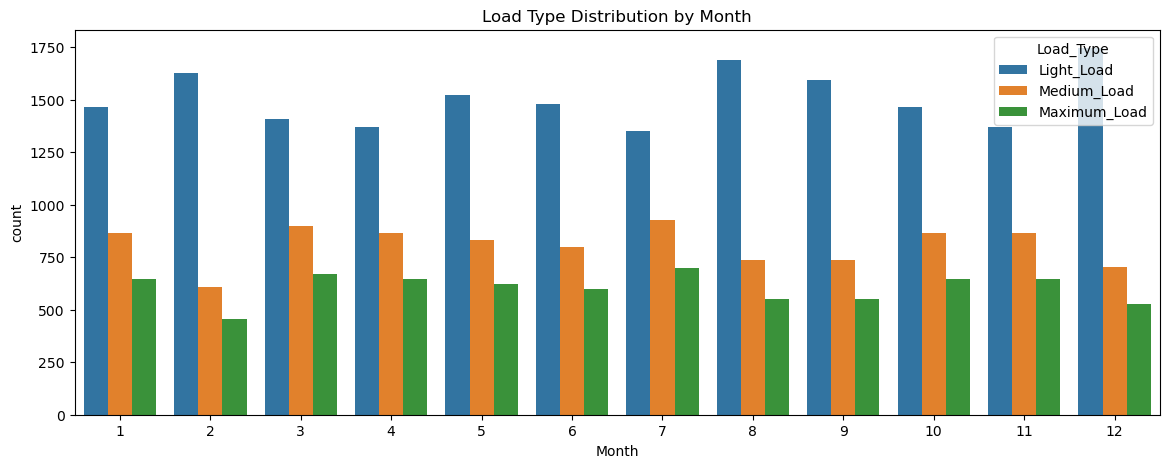

In [54]:
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x=df['Date_Time'].dt.month, hue='Load_Type')
plt.title("Load Type Distribution by Month")
plt.xlabel("Month")
plt.show()

In [40]:
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(
    X_train,
    y_train_encoded
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [41]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train_encoded
)

DecisionTreeClassifier(random_state=42)

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train_encoded
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [43]:
extra_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(
    X_train,
    y_train_encoded
)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [44]:
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

In [45]:
results = []

results.append(
    evaluate_model(
        logistic_model,
        X_test,
        y_test_encoded,
        'Logistic Regression'
    )
)

results.append(
    evaluate_model(
        dt_model,
        X_test,
        y_test_encoded,
        'Decision Tree'
    )
)

results.append(
    evaluate_model(
        rf_model,
        X_test,
        y_test_encoded,
        'Random Forest'
    )
)

results.append(
    evaluate_model(
        extra_model,
        X_test,
        y_test_encoded,
        'Extra Trees'
    )
)

In [46]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.920726,0.929993,0.920726,0.922332
1,Decision Tree,0.896204,0.913210,0.896204,0.898291
3,Extra Trees,0.880081,0.894766,0.880081,0.882677
0,Logistic Regression,0.644609,0.704005,0.644609,0.663661


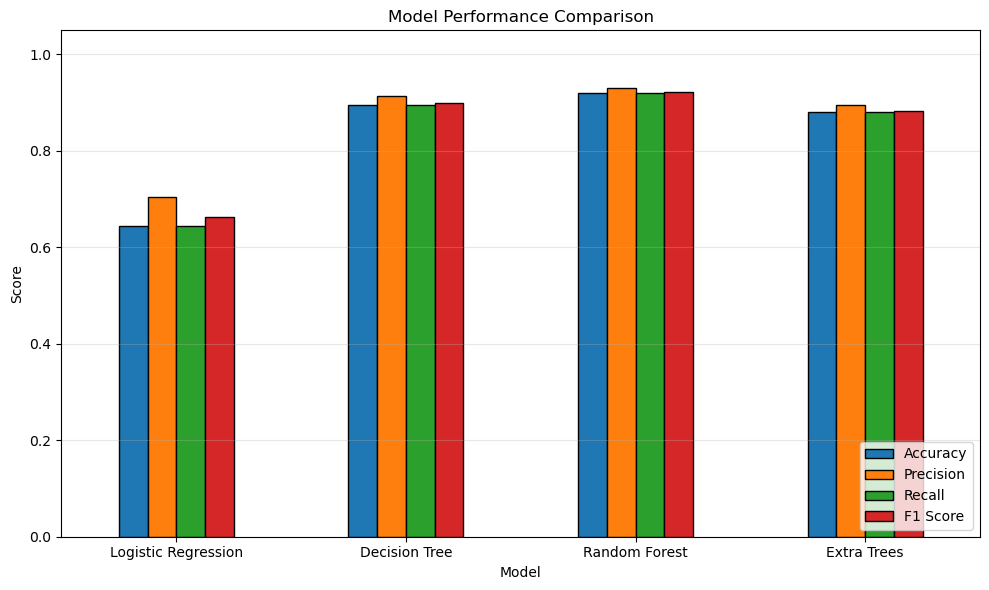

In [59]:
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(10,6), rot=0, edgecolor='black'
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
final_model = rf_model

final_predictions = final_model.predict(X_test)

In [48]:
print(
    classification_report(
        y_test_encoded,
        final_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  Light_Load       0.99      0.93      0.96      1745
Maximum_Load       0.92      0.84      0.87       528
 Medium_Load       0.79      0.97      0.87       704

    accuracy                           0.92      2977
   macro avg       0.90      0.91      0.90      2977
weighted avg       0.93      0.92      0.92      2977



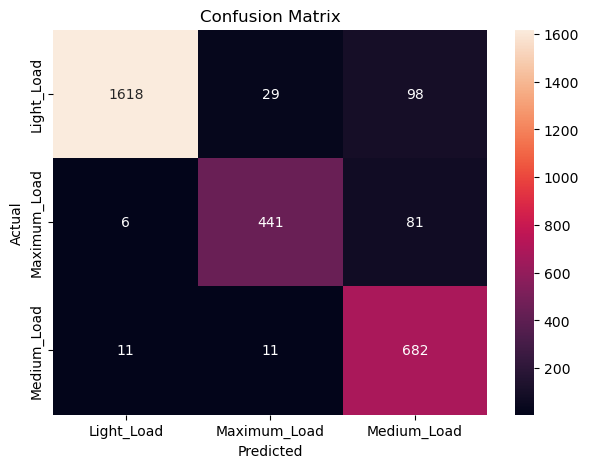

In [49]:
cm = confusion_matrix(
    y_test_encoded,
    final_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [50]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

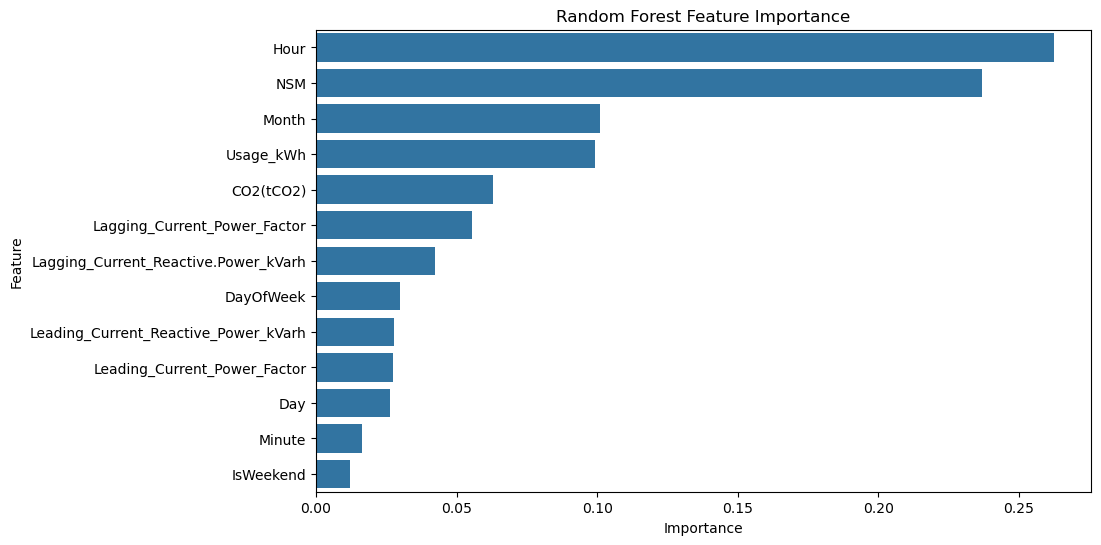

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.show()

In [52]:
# ==========================================
# MANUAL LOAD TYPE PREDICTION
#Just for understanding
# ==========================================

# Enter your values here
manual_data = pd.DataFrame([{
    'Usage_kWh': 4.5,
    'Lagging_Current_Reactive.Power_kVarh': 2.1,
    'Leading_Current_Reactive_Power_kVarh': 1.2,
    'CO2(tCO2)': 0.01,
    'Lagging_Current_Power_Factor': 0.95,
    'Leading_Current_Power_Factor': 0.99,
    'NSM': 15000,
    'Hour': 8,
    'Minute': 0,
    'Day': 15,
    'Month': 12,
    'DayOfWeek': 4,
    'IsWeekend': 0
}])


# Arrange features in the correct order
manual_data = manual_data[features]


# Apply the same imputer used during training
manual_data_imputed = pd.DataFrame(
    imputer.transform(manual_data),
    columns=manual_data.columns
)


# Predict
prediction_encoded = final_model.predict(manual_data_imputed)

prediction = label_encoder.inverse_transform(
    prediction_encoded
)


# Display result
print("Predicted Load Type:", prediction[0])

Predicted Load Type: Light_Load


In [53]:
probabilities = final_model.predict_proba(manual_data_imputed)[0]

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities
):
    print(f"{class_name}: {probability:.2%}")

Light_Load: 90.00%
Maximum_Load: 4.50%
Medium_Load: 5.50%
